# EDA file van Milan Martens

In dit notebook wordt er gefocust op mijn EDA toepassing op de train dataset.
Deze dataset wordt in gelezen door pandas en numpy.

Door heen dit notebook worden de dimensies bijgehouden van het dataframe. Zo kan er goed worden bijgehouden hoe hard onze dimensies verklijnen. 


## Belangrijke imports

In [406]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Van messey data naar clean data

Als eerste stap moeten we de dataset naar een pandas dataframe omzetten. Zo kunnen we goed zien met wat we werken.

In [407]:
df = pd.read_csv("../csv/train/train_CarBreakDown.csv")
df

,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,494744.972722,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
2,1304,Hyundai,1.0,188558.432414,6678.958321,11726.320455,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
4,47,NaN,10.0,118366.394287,4222.193011,12551.181627,65.766074,47.159242,low,diesel,77.368891,6.724967,winter,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,NaN,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


### Cleaning van de data

Nu dat we ons pandas dataframe hebben kunnen we starten met cleanen. Laten beginnen met het checken van vehicle_brand colom op NaN waarden. 

#### Colum vehicle_brand

In [408]:
df["vehicle_brand"].unique()

<StringArray>
[    'Toyota',    'Hyundai',          nan,    'Renault',      'Volvo',
 'Volkswagen',       'Ford',        'BMW',        'Kia',      'other']
Length: 10, dtype: str

In [409]:
df["vehicle_brand"].isna().sum()


np.int64(21)

Zoals we kunnen zien uit de code block 1, hebben we 8 merken van auto's en 1 "other" categorie. Ook zitten we hier met nan's. Dit betekent dus dat we nu op een probleem lopen.


**Wat doen we met nan records?**

We kunnen de **hele row hiervoor deleten**. Dit gaat in de long run zorgen dat we 21 rijen, te zien in code block 2, minder gaan hebben van de 1050 rijen dit is een reductie van 2% van de orginele dataset.

We kunnen ook de **hele vehical_brand colum deleten**. Dit zal ervoor zorgen dat ons model in de toekomst geen rekening gaat kunnen houden met de brand van de auto.

De vraag dat we nu dan moeten stellen is:

**Moet ons model perse weten over welk merk het gaat? Is 21 rijen van 1050 zo belangrijk?**

Ik denk voor onze use case, dat een auto kapot gaat binnen 30 dagen of niet, het **vrij belangrijk is dat we het automerk kennen**. Elke merk auto is anders en hier moet rekening mee gehouden worden. En in vergelijking met een reductie van 2% is dat denk ik niet zo erg. We verliezen niet heel veel dan als we een hele colum zouden verwijderen.


In [410]:
df = df.dropna(subset=["vehicle_brand"])
df


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,494744.972722,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
2,1304,Hyundai,1.0,188558.432414,6678.958321,11726.320455,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
5,606,Renault,1.0,209439.442769,7156.897259,3527.010815,52.147399,1.458703,high,hybrid,57.117174,7.676373,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,NaN,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


#### Colum vehicle_age_years

In [411]:
df["vehicle_age_years"].unique()

array([20.,  0.,  1.,  5., 11., 19.,  4.,  2., 14.,  8.,  7.,  6.,  3.,
       13., 10.,  9., 12., 16., 15., 17., nan, 18.])

In [412]:
df["vehicle_age_years"].isna().sum()

np.int64(16)

In [413]:
df["vehicle_age_years"].describe()


count    1013.000000
mean        9.385982
std         5.746118
min         0.000000
25%         5.000000
50%         9.000000
75%        14.000000
max        20.000000
Name: vehicle_age_years, dtype: float64

Zoals in de vorige colum lopen we hier ook op nan's dit is te zien in code block 1, waar alle leeftijden tussen 0 en 20 vallen. En uit code block 2 kunnen we zien dat het hier gaat over 16 rijen waar de value een nan is. Dit betekent dus dat we weer op een probleem lopen.

**Wat doen we met nan records?**

We kunnen de **hele row hiervoor deleten**. Dit gaat in de long run zorgen dat we 16 rijen, te zien in code block 2, minder gaan hebben van de 1029 rijen dit is een reductie van 1.6% van de nieuwe dataset..

We kunnen ook de **hele vehicle_age_years colum deleten**. Dit zal ervoor zorgen dat ons model in de toekomst geen rekening gaat kunnen houden met de leeftijd van de auto.

We kunnen ook de **nans vervangen door de gemiddelde leeftijd**. Dit zorgt ervoor dat we bias voorkomen en ons model later niet scheeftrekken. En natuurlijk blijven we de rest van onze data behouden.


De vraag dat we nu dan moeten stellen is:

**Moet ons model perse weten hoe oud de auto is? Is 16 rijen van 1029 zo belangrijk? Heeft het vervangen van de nans met de gemiddelde waarde veel nut?**

Ik denk voor onze use case, dat een auto kapot gaat binnen 30 dagen of niet, het vrij belangrijk is dat we het de leeftijd van de auto kennen. De leeftijd speelt natuurlijk een cruciale rol in de levensduur van een auto. We kunnen tevens wel de **nans vervangen met de gemiddelde leeftijd** dit is omdat, door code block 3, we kunnen zeggen dat dit ongeveer normaal verdeeld is. Dit zorgt dat we de data gewoon kunnen vervangen door het gemiddelde. Hierdoor verliezen we geen data, en omdat het gemiddelde (9.385982) dicht bij de mediaan (9) ligt, verandert de verdeling nauwelijks.

In [414]:
df["vehicle_age_years"] = df["vehicle_age_years"].fillna(df["vehicle_age_years"].mean())
df["vehicle_age_years"].describe()


count    1029.000000
mean        9.385982
std         5.701225
min         0.000000
25%         5.000000
50%         9.000000
75%        14.000000
max        20.000000
Name: vehicle_age_years, dtype: float64

Zoals je kan zien, uit code snippet 4, is er niets veranderd naar de conversie van nans => gemideldes.

In [415]:
df


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,494744.972722,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
2,1304,Hyundai,1.0,188558.432414,6678.958321,11726.320455,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
5,606,Renault,1.0,209439.442769,7156.897259,3527.010815,52.147399,1.458703,high,hybrid,57.117174,7.676373,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,NaN,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


#### Colum mileage_km

In [416]:
df["mileage_km"].describe()

count    1.012000e+03
mean     3.712132e+06
std      2.612033e+07
min     -1.829042e+02
25%      8.369581e+04
50%      1.203610e+05
75%      1.683877e+05
max      3.734539e+08
Name: mileage_km, dtype: float64

Het heeft geen nut volgende code snippet te runnen momenteel.
````
df["mileage_km].unique()
````
Dit heeft te maken met het feit dat alle afstanden allemaal uniek zijn. 


In [417]:
df["mileage_km"].isnull().sum()



np.int64(17)

We kunnen uit code snippet 2 afleiden dat we met 17 nans zitten. Dit is een heel ambetant probleem.

**Wat doen we met nan waardes?**

We kunnen de **hele row hiervoor deleten**. Dit gaat in de long run zorgen dat we 17 rijen, te zien in code block 2, minder gaan hebben van de 1029 rijen dit is een reductie van 1.65% van de nieuwe dataset.

We kunnen ook de **hele mileage_km colum deleten**. Dit zal ervoor zorgen dat ons model in de toekomst geen rekening gaat kunnen houden met de gereden afstand van de auto.

We kunnen ook de **negatieve waarde vervangen door de mediaan**. Dit zorgt ervoor dat we bias voorkomen en ons model later niet scheeftrekken. En natuurlijk blijven we de rest van onze data behouden. We gebruiken mediaan in plaats van gemiddelde omdat gemiddelde en mediaan vervanelkaar liggen en als we dus gemiddelde zouden gebruiken het een te grote in pact zou hebben op onze verdeling.


De vraag dat we nu dan moeten stellen is:

**Moet ons model perse weten hoe ver een auto heeft gereden? Is 17 rij van 1029 zo belangrijk? Heeft het vervangen van de negatieve waarde met de mediaan waarde veel nut?**

Ik denk voor onze use case, dat een auto kapot gaat binnen 30 dagen of niet, het vrij belangrijk is dat we hoe ver de auto al heeft gereden van de auto kennen. En ik denk dat het veel gemakkelijker is om **gewoon 17 nan rijen te verwijderen**. Dit gebeurt outomatisch bij het filteren wat we sebiet gaan moeten doen. We hoeven hier dus geen extra code voor te schrijven LUCKY.

In [418]:
(df["mileage_km"] < 0).sum()


np.int64(1)

Maar we kunnen afleiden uit code snippet 1 dat we met een paar negatieve values zitten. laten we deze eerst eruit halen. een auto kan nooit achteruit rijden. Hier lopen we natuurlijk op een probleem

**Wat doen we met negatieve waardes?**

We kunnen de **hele row hiervoor deleten**. Dit gaat in de long run zorgen dat we 1 rij, te zien in code block 3, minder gaan hebben van de 1029 rijen dit is een reductie van 0.09% van de nieuwe dataset.

We kunnen ook de **hele mileage_km colum deleten**. Dit zal ervoor zorgen dat ons model in de toekomst geen rekening gaat kunnen houden met de gereden afstand van de auto.

We kunnen ook de **negatieve waarde vervangen door de mediaan**. Dit zorgt ervoor dat we bias voorkomen en ons model later niet scheeftrekken. En natuurlijk blijven we de rest van onze data behouden. We gebruiken mediaan in plaats van gemiddelde omdat gemiddelde en mediaan vervanelkaar liggen en als we dus gemiddelde zouden gebruiken het een te grote in pact zou hebben op onze verdeling.

We kunnen ook de **negatieve inputs naar 0 zetten**. Dit zal ervoor zorgen dat we al onze data behouden en geen rijen moeten verwijderen.


De vraag dat we nu dan moeten stellen is:

**Moet ons model perse weten hoe ver een auto heeft gereden? Is 1 rij van 1029 zo belangrijk? Heeft het vervangen van de negatieve waarde met de mediaan waarde veel nut? Heeft het veel nut om de negatieve waarde naar 0 te zetten**

Ik denk voor onze use case, dat een auto kapot gaat binnen 30 dagen of niet, het vrij belangrijk is dat we hoe ver de auto al heeft gereden van de auto kennen. En ik denk dat het vrij gemakkelijk is om **gewoon 1 negatieve rij te verwijderen**.

In [419]:
df = df[df["mileage_km"] >= 0]

df["mileage_km"].describe()



count    1.011000e+03
mean     3.715804e+06
std      2.613300e+07
min      4.916924e+02
25%      8.384472e+04
50%      1.204198e+05
75%      1.686027e+05
max      3.734539e+08
Name: mileage_km, dtype: float64

In [420]:
(df["mileage_km"] > 10**6).sum()

np.int64(27)

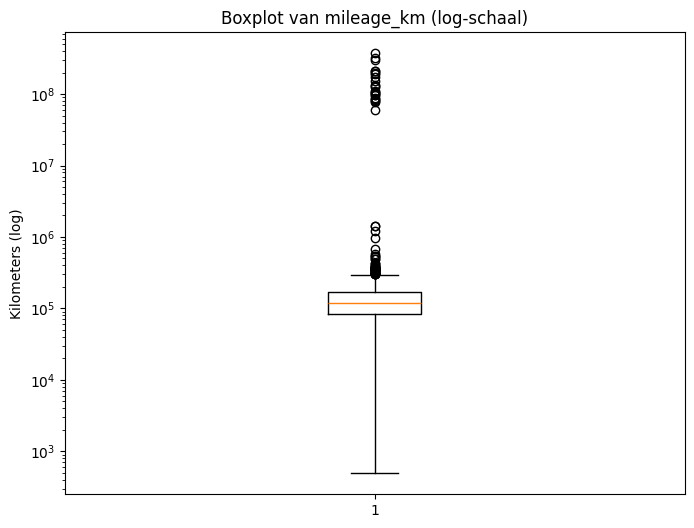

In [421]:
plt.figure(figsize=(8,6))
plt.boxplot(df["mileage_km"], showfliers=True)
plt.yscale("log")  # Log-schaal
plt.title("Boxplot van mileage_km (log-schaal)")
plt.ylabel("Kilometers (log)")
plt.show()


Door het plotten van de data op log schaal kunnen we duidelijk zien dat we een hoop uitschieters hebben aan de.


![logaritmische box plot van de mileage in km ](../assets/Milan/box_mileage_km_log_met_uitschieters.png)


Kijkend naar de data van de uitschieters kunnen we zien dat de meeste meer dan 1.000.000 km zouden hebben gerijden op max 20 jaar. Want dat is de max vehical_age_years. die we daarnet hebben gevoden. Dit lijkt mij zeer onwaarschijnlijk. Dan komt natuurlijk weer de vraag.


**Wat doen we met waardes <= 10^6?**

We kunnen de **hele row hiervoor deleten**. Dit gaat in de long run zorgen dat we 27 rijen, te zien in code block 2, minder gaan hebben van de 1029 rijen dit is een reductie van 2.6% van de nieuwe dataset.

We kunnen ook de **hele mileage_km colum deleten**. Dit zal ervoor zorgen dat ons model in de toekomst geen rekening gaat kunnen houden met de gereden afstand van de auto.

We kunnen ook de **waardes <= 10^6 vervangen door de mediaan**. Dit zorgt ervoor dat we bias voorkomen en ons model later niet scheeftrekken. En natuurlijk blijven we de rest van onze data behouden. We gebruiken mediaan in plaats van gemiddelde omdat gemiddelde en mediaan vervanelkaar liggen en als we dus gemiddelde zouden gebruiken het een te grote in pact zou hebben op onze verdeling.

De vraag dat we nu dan moeten stellen is:

**Moet ons model perse weten hoe ver een auto heeft gereden? Is 27 rij van 1029 zo belangrijk? Heeft het vervangen van de waardes <= 10^6 met de mediaan waarde veel nut?**

Ik denk voor onze use case, dat een auto kapot gaat binnen 30 dagen of niet, het vrij belangrijk is dat we hoe ver de auto al heeft gereden van de auto kennen. En ik denk dat het vrij gemakkelijk is om **gewoon 27 rijen te verwijderen** dit is omdat dit echt grote uitliers zijn, dit kan je goed zien op de image.

In [422]:
df = df[df["mileage_km"] <= 10**6]
df["mileage_km"].describe()

count       984.000000
mean     135722.205664
std       83541.533976
min         491.692384
25%       82597.331483
50%      118477.405319
75%      163733.485614
max      952591.000000
Name: mileage_km, dtype: float64

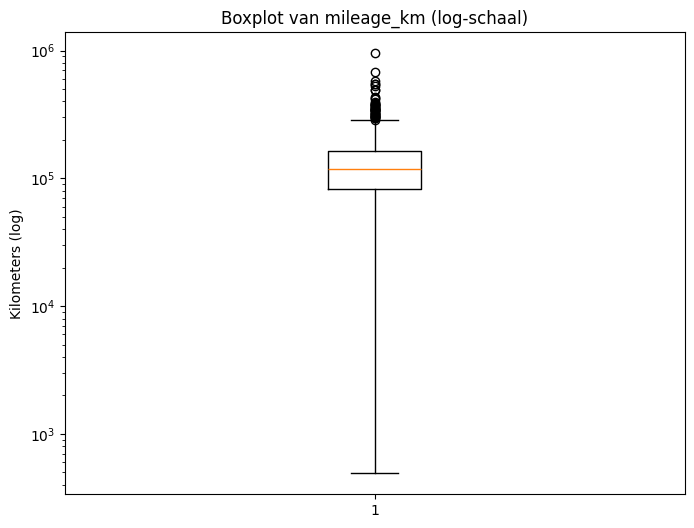

In [423]:
plt.figure(figsize=(8,6))
plt.boxplot(df["mileage_km"], showfliers=True)
plt.yscale("log")  # Log-schaal
plt.title("Boxplot van mileage_km (log-schaal)")
plt.ylabel("Kilometers (log)")
plt.show()


Door het plotten van de data op log schaal kunnen we duidelijk zien dat we nog een aantal uitschieters hebben. maar dit zijn "realistischere" afstanden dat kunnen gereden worden op 20 jaar tijd.


![logaritmische box plot van de mileage in km ](../assets/Milan/box_mileage_km_log_zonder_uitschieters.png)

In [426]:
df

,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,494744.972722,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
2,1304,Hyundai,1.0,188558.432414,6678.958321,11726.320455,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
5,606,Renault,1.0,209439.442769,7156.897259,3527.010815,52.147399,1.458703,high,hybrid,57.117174,7.676373,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,NaN,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0
